In [4]:
!pip install kagglehub

In [21]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
postings_data = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "asaniczka/data-science-job-postings-and-skills",
    "job_postings.csv"
)
skills_data = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "asaniczka/data-science-job-postings-and-skills",
    "job_skills.csv"
)
summary_data = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "asaniczka/data-science-job-postings-and-skills",
    "job_summary.csv"
)


/tmp/ipython-input-3046388926.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  postings_data = kagglehub.load_dataset(


Using Colab cache for faster access to the 'data-science-job-postings-and-skills' dataset.


/tmp/ipython-input-3046388926.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  skills_data = kagglehub.load_dataset(


Using Colab cache for faster access to the 'data-science-job-postings-and-skills' dataset.


/tmp/ipython-input-3046388926.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  summary_data = kagglehub.load_dataset(


Using Colab cache for faster access to the 'data-science-job-postings-and-skills' dataset.


In [8]:
postings_data.head()

,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite
3,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:30:55.796572+00,Finished NER,t,t,f,Senior Data Warehouse Developer / Architect,Morph Enterprise,"Harrisburg, PA",2024-01-12,Lebanon,United States,Architect,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/lead-data-e...,2024-01-21 08:08:58.312124+00,Finished NER,t,t,f,Lead Data Engineer,Dice,"Plano, TX",2024-01-14,McKinney,United States,Maintenance Data Analyst,Mid senior,Onsite


In [9]:
skills_data.head()


,job_link,job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,"Machine Learning, Programming, Python, Scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."
2,https://www.linkedin.com/jobs/view/senior-etl-...,"ETL, Data Integration, Data Transformation, Da..."
3,https://www.linkedin.com/jobs/view/senior-data...,"Data Lakes, Data Bricks, Azure Data Factory Pi..."
4,https://www.linkedin.com/jobs/view/lead-data-e...,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S..."


In [10]:
summary_data.head()


,job_link,job_summary
0,https://www.linkedin.com/jobs/view/senior-mach...,Company Description\nJobs for Humanity is part...
1,https://www.linkedin.com/jobs/view/principal-s...,Who We Are\nAurora (Nasdaq: AUR) is delivering...
2,https://www.linkedin.com/jobs/view/senior-etl-...,"Location: New York City, NY\nPosition Summary\..."
3,https://www.linkedin.com/jobs/view/senior-data...,Responsibilities:\nCandidate must have signifi...
4,https://www.linkedin.com/jobs/view/lead-data-e...,Dice is the leading career destination for tec...


In [11]:
postings_data.columns

Index(['job_link', 'last_processed_time', 'last_status', 'got_summary',
       'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location',
       'first_seen', 'search_city', 'search_country', 'search_position',
       'job_level', 'job_type'],
      dtype='object')

In [13]:
skills_data.columns


Index(['job_link', 'job_skills'], dtype='object')

In [12]:
summary_data.columns


Index(['job_link', 'job_summary'], dtype='object')

In [23]:
# Merge Postings, Skills and Summary data
merge = pd.merge(postings_data,skills_data,on = 'job_link')
df = pd.merge(merge,summary_data, on='job_link')
df

,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills,job_summary
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite,"Machine Learning, Programming, Python, Scala, ...",Company Description\nJobs for Humanity is part...
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,...",Who We Are\nAurora (Nasdaq: AUR) is delivering...
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite,"ETL, Data Integration, Data Transformation, Da...","Location: New York City, NY\nPosition Summary\..."
3,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:30:55.796572+00,Finished NER,t,t,f,Senior Data Warehouse Developer / Architect,Morph Enterprise,"Harrisburg, PA",2024-01-12,Lebanon,United States,Architect,Mid senior,Onsite,"Data Lakes, Data Bricks, Azure Data Factory Pi...",Responsibilities:\nCandidate must have signifi...
4,https://www.linkedin.com/jobs/view/lead-data-e...,2024-01-21 08:08:58.312124+00,Finished NER,t,t,f,Lead Data Engineer,Dice,"Plano, TX",2024-01-14,McKinney,United States,Maintenance Data Analyst,Mid senior,Onsite,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S...",Dice is the leading career destination for tec...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12212,https://uk.linkedin.com/jobs/view/data-reporti...,2024-01-21 07:11:22.099082+00,Finished NER,t,t,f,"Data Reporting Manager, FOOTBALL ASSOCIATION",Guardian Jobs,"Wembley, England, United Kingdom",2024-01-16,High Wycombe,United Kingdom,Manager Forms Analysis,Mid senior,Onsite,"Dashboard development, Reporting, Power BI, SQ...","FOOTBALL ASSOCIATION\nMake an impact, on and o..."
12213,https://www.linkedin.com/jobs/view/corporate-a...,2024-01-19 15:10:41.177008+00,Finished NER,t,t,f,Corporate AML Alert Investigation Specialist,"Glacier Bancorp, Inc.","Kalispell, MT",2024-01-14,Montana,United States,Teller,Mid senior,Onsite,"Investigation, Antimoney laundering, Fraud, Ba...",About The Role\nPlease note: review of applica...
12214,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:20:19.036168+00,Finished NER,t,t,f,Senior Data Scientist,Highnote,"San Francisco, CA",2024-01-16,San Rafael,United States,Mathematician,Mid senior,Onsite,"Data Science, Quantitative Modeling, SQL, Data...",About Highnote\nFounded in 2020 by a team of l...
12215,https://www.linkedin.com/jobs/view/senior-data...,2024-01-19 23:25:28.107523+00,Finished NER,t,t,f,Senior Data Engineer,CompSource Mutual Insurance Company,"Oklahoma City, OK",2024-01-16,Arcadia,United States,Protection Engineer,Mid senior,Onsite,"Data Engineering, Data Quality, SQL, Python, T...",Are you an experienced data engineer in Oklaho...


In [19]:
df.columns

Index(['job_link', 'last_processed_time', 'last_status', 'got_summary',
       'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location',
       'first_seen', 'search_city', 'search_country', 'search_position',
       'job_level', 'job_type', 'job_skills', 'job_summary'],
      dtype='object')

In [24]:
# Remove the null values
df.isna().sum()

,0
job_link,0
last_processed_time,0
last_status,0
got_summary,0
got_ner,0
is_being_worked,0
job_title,0
company,0
job_location,1
first_seen,0


In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.dropna(inplace=True)

In [27]:
df.isna().sum()

,0
job_link,0
last_processed_time,0
last_status,0
got_summary,0
got_ner,0
is_being_worked,0
job_title,0
company,0
job_location,0
first_seen,0


In [28]:
df['skill_count'] = df['job_skills'].str.split(', ').apply(len)
df

,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills,job_summary,skill_count
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite,"Machine Learning, Programming, Python, Scala, ...",Company Description\nJobs for Humanity is part...,27
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,...",Who We Are\nAurora (Nasdaq: AUR) is delivering...,23
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite,"ETL, Data Integration, Data Transformation, Da...","Location: New York City, NY\nPosition Summary\...",27
3,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:30:55.796572+00,Finished NER,t,t,f,Senior Data Warehouse Developer / Architect,Morph Enterprise,"Harrisburg, PA",2024-01-12,Lebanon,United States,Architect,Mid senior,Onsite,"Data Lakes, Data Bricks, Azure Data Factory Pi...",Responsibilities:\nCandidate must have signifi...,41
4,https://www.linkedin.com/jobs/view/lead-data-e...,2024-01-21 08:08:58.312124+00,Finished NER,t,t,f,Lead Data Engineer,Dice,"Plano, TX",2024-01-14,McKinney,United States,Maintenance Data Analyst,Mid senior,Onsite,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S...",Dice is the leading career destination for tec...,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12212,https://uk.linkedin.com/jobs/view/data-reporti...,2024-01-21 07:11:22.099082+00,Finished NER,t,t,f,"Data Reporting Manager, FOOTBALL ASSOCIATION",Guardian Jobs,"Wembley, England, United Kingdom",2024-01-16,High Wycombe,United Kingdom,Manager Forms Analysis,Mid senior,Onsite,"Dashboard development, Reporting, Power BI, SQ...","FOOTBALL ASSOCIATION\nMake an impact, on and o...",18
12213,https://www.linkedin.com/jobs/view/corporate-a...,2024-01-19 15:10:41.177008+00,Finished NER,t,t,f,Corporate AML Alert Investigation Specialist,"Glacier Bancorp, Inc.","Kalispell, MT",2024-01-14,Montana,United States,Teller,Mid senior,Onsite,"Investigation, Antimoney laundering, Fraud, Ba...",About The Role\nPlease note: review of applica...,62
12214,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:20:19.036168+00,Finished NER,t,t,f,Senior Data Scientist,Highnote,"San Francisco, CA",2024-01-16,San Rafael,United States,Mathematician,Mid senior,Onsite,"Data Science, Quantitative Modeling, SQL, Data...",About Highnote\nFounded in 2020 by a team of l...,14
12215,https://www.linkedin.com/jobs/view/senior-data...,2024-01-19 23:25:28.107523+00,Finished NER,t,t,f,Senior Data Engineer,CompSource Mutual Insurance Company,"Oklahoma City, OK",2024-01-16,Arcadia,United States,Protection Engineer,Mid senior,Onsite,"Data Engineering, Data Quality, SQL, Python, T...",Are you an experienced data engineer in Oklaho...,31


In [32]:
df.columns

Index(['job_link', 'last_processed_time', 'last_status', 'got_summary',
       'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location',
       'first_seen', 'search_city', 'search_country', 'search_position',
       'job_level', 'job_type', 'job_skills', 'job_summary', 'skill_count'],
      dtype='object')

In [33]:
df.drop(columns=['got_ner', 'is_being_worked'], inplace=True)

In [34]:
df.drop(columns=['last_status'], inplace=True)

In [39]:
df.drop(columns=['got_summary'], inplace=True)


In [40]:
df.drop(columns=['last_processed_time'], inplace=True)

In [58]:
df.columns

Index(['job_link', 'job_title', 'company', 'job_location', 'first_seen',
       'search_city', 'search_country', 'search_position', 'job_level',
       'job_type', 'job_skills', 'job_summary', 'skill_count'],
      dtype='object')

In [61]:
# Nettoyage texte
df['job_title'] = df['job_title'].str.lower().str.strip()
df['job_skills'] = df['job_skills'].str.lower().str.strip()
df['job_location'] = df['job_location'].str.lower().str.strip()

In [62]:
df['company'] = df['company'].str.lower().str.strip()
df['job_summary'] = df['job_summary'].str.lower().str.strip()

In [63]:
# Suppression caractères spéciaux inutiles
df['job_summary'] = df['job_summary'].str.replace(r'[^\w\s,.]', ' ', regex=True)
df['job_summary'] = df['job_summary'].str.replace(r'\s+', ' ', regex=True)

In [64]:
df['city'] = df['job_location'].str.split(',').str[0].str.strip()
df['country'] = df['search_country'].str.lower().str.strip()

In [65]:
df.head()

,job_link,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills,job_summary,skill_count,city,country
0,https://www.linkedin.com/jobs/view/senior-mach...,senior machine learning engineer,jobs for humanity,"new haven, ct",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite,"machine learning, programming, python, scala, ...",company description jobs for humanity is partn...,27,new haven,united states
1,https://www.linkedin.com/jobs/view/principal-s...,"principal software engineer, ml accelerators",aurora,"san francisco, ca",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite,"c++, python, pytorch, tensorflow, mxnet, cuda,...",who we are aurora nasdaq aur is delivering the...,23,san francisco,united states
2,https://www.linkedin.com/jobs/view/senior-etl-...,senior etl data warehouse specialist,adame services llc,"new york, ny",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite,"etl, data integration, data transformation, da...","location new york city, ny position summary ou...",27,new york,united states
3,https://www.linkedin.com/jobs/view/senior-data...,senior data warehouse developer / architect,morph enterprise,"harrisburg, pa",2024-01-12,Lebanon,United States,Architect,Mid senior,Onsite,"data lakes, data bricks, azure data factory pi...",responsibilities candidate must have significa...,41,harrisburg,united states
4,https://www.linkedin.com/jobs/view/lead-data-e...,lead data engineer,dice,"plano, tx",2024-01-14,McKinney,United States,Maintenance Data Analyst,Mid senior,Onsite,"java, scala, python, rdbms, nosql, redshift, s...",dice is the leading career destination for tec...,17,plano,united states


In [60]:
# Vérifications finales
print("Valeurs manquantes:", df.isnull().sum())
print("Doublons:", df.duplicated().sum())
print("Types de données:", df.dtypes)
print("Taille du dataset:", df.shape)


Valeurs manquantes: job_link           0
job_title          0
company            0
job_location       0
first_seen         0
search_city        0
search_country     0
search_position    0
job_level          0
job_type           0
job_skills         0
job_summary        0
skill_count        0
dtype: int64
Doublons: 0
Types de données: job_link                   object
job_title                  object
company                    object
job_location               object
first_seen         datetime64[ns]
search_city                object
search_country             object
search_position            object
job_level                  object
job_type                   object
job_skills                 object
job_summary                object
skill_count                 int64
dtype: object
Taille du dataset: (12211, 13)


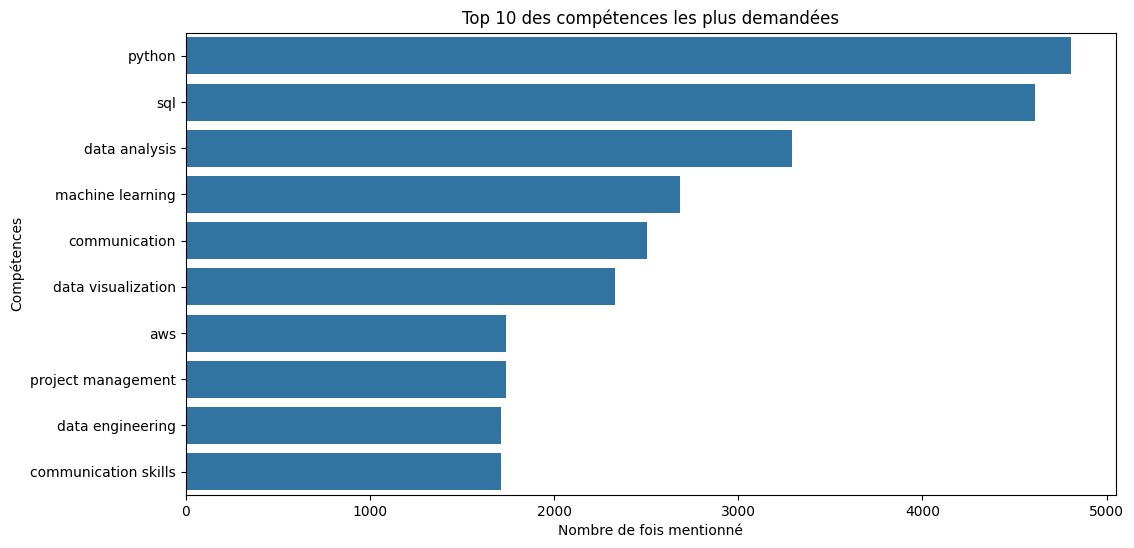

In [45]:
# 1. Analyse des compétences
# Compter les compétences les plus fréquentes
skill_counts = df['job_skills'].str.split(', ').explode().value_counts()
# Visualiser les compétences les plus fréquentes
plt.figure(figsize=(12, 6))
sns.barplot(x=skill_counts.values[:10], y=skill_counts.index[:10])
plt.title('Top 10 des compétences les plus demandées')
plt.xlabel('Nombre de fois mentionné')
plt.ylabel('Compétences')
plt.show()

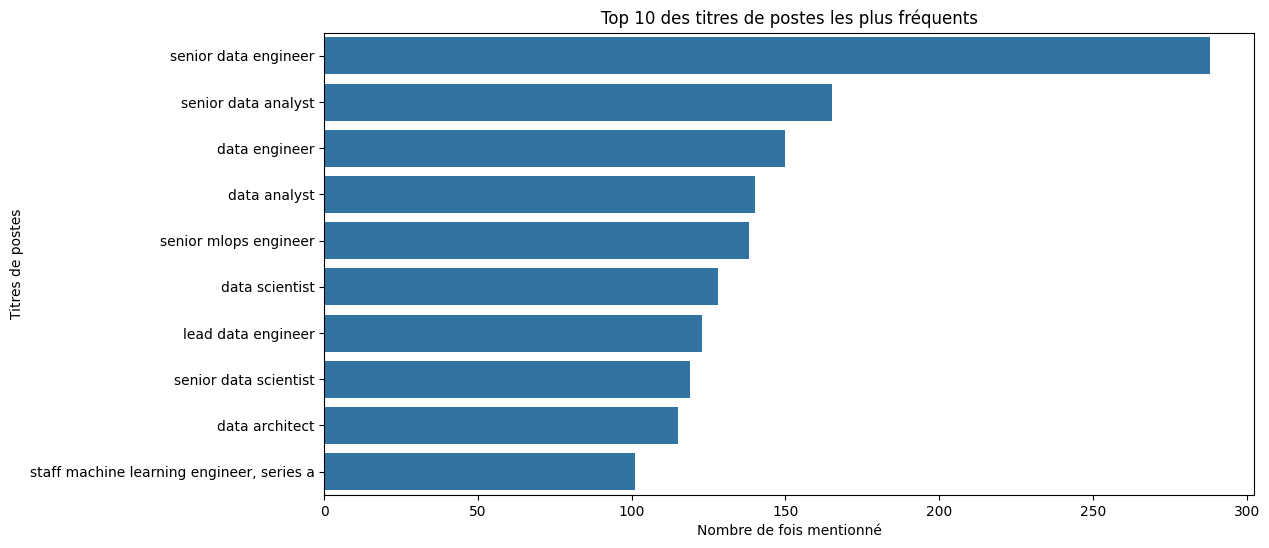

In [46]:
# 2. Analyse des titres de postes
# Compter les titres de postes les plus fréquents
title_counts = df['job_title'].value_counts()
# Visualiser les titres de postes les plus fréquents
plt.figure(figsize=(12, 6))
sns.barplot(x=title_counts.values[:10], y=title_counts.index[:10])
plt.title('Top 10 des titres de postes les plus fréquents')
plt.xlabel('Nombre de fois mentionné')
plt.ylabel('Titres de postes')
plt.show()

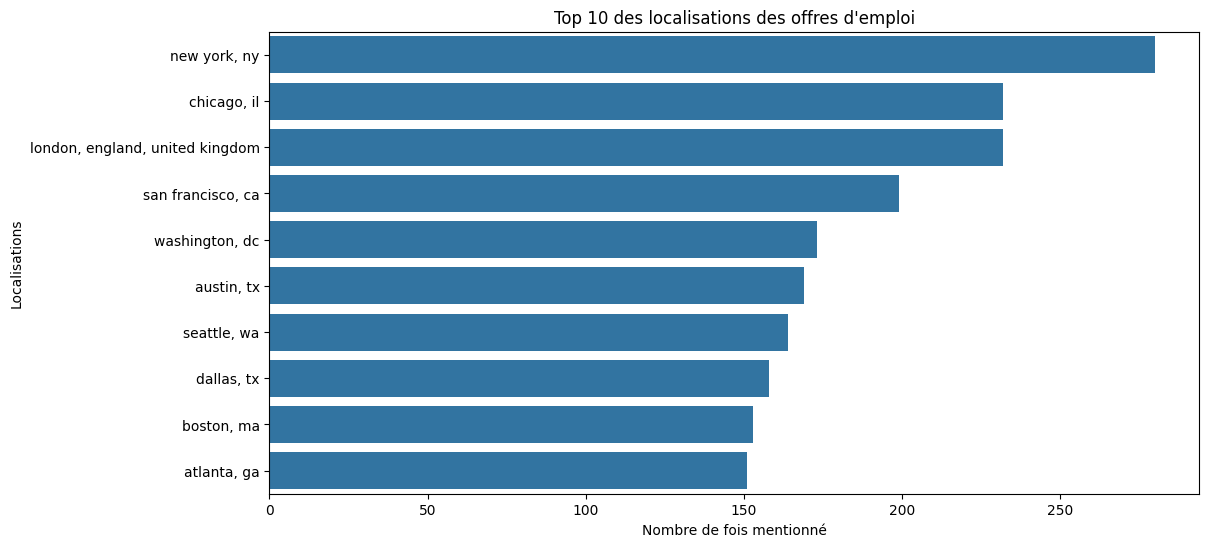

In [44]:
# 3. Analyse des localisations
# Compter les localisations les plus fréquentes
location_counts = df['job_location'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=location_counts.values[:10], y=location_counts.index[:10])
plt.title('Top 10 des localisations des offres d\'emploi')
plt.xlabel('Nombre de fois mentionné')
plt.ylabel('Localisations')
plt.show()

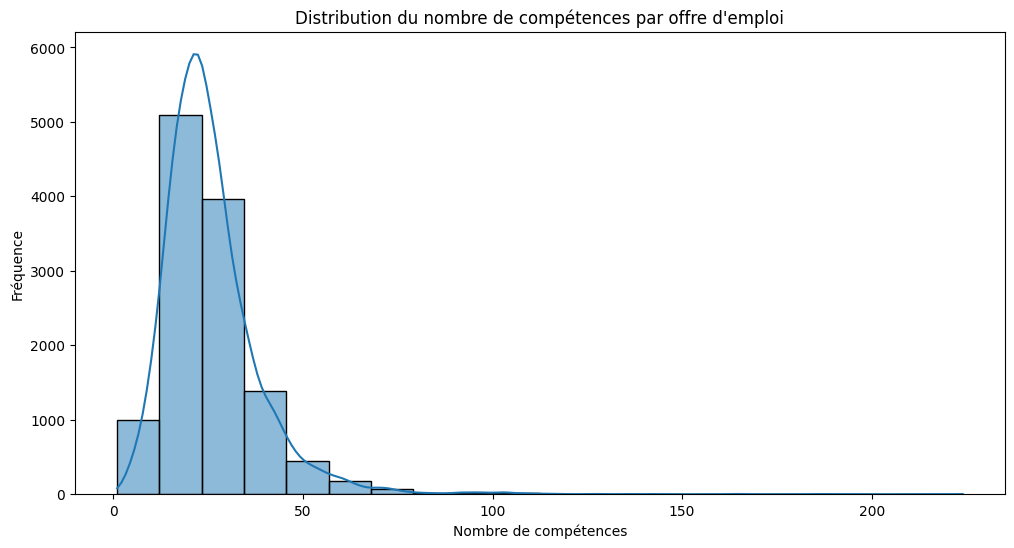

In [47]:
# 4. Visualiser la distribution du nombre de compétences par offre
plt.figure(figsize=(12, 6))
sns.histplot(df['skill_count'], bins=20, kde=True)
plt.title('Distribution du nombre de compétences par offre d\'emploi')
plt.xlabel('Nombre de compétences')
plt.ylabel('Fréquence')
plt.show()

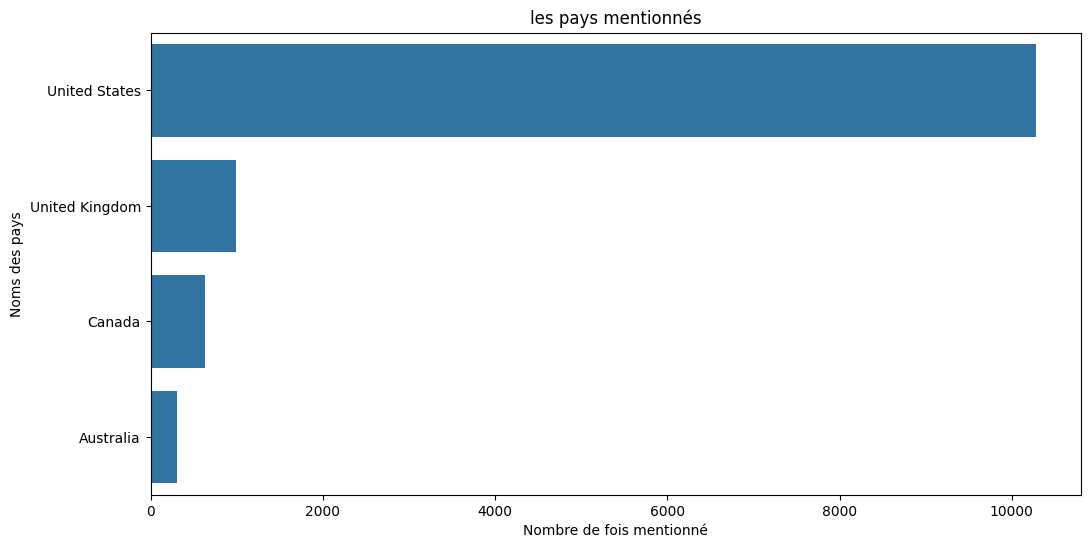

In [52]:
country_counts = df['search_country'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.values[:10], y=country_counts.index[:10])
plt.title('les pays mentionnés')
plt.xlabel('Nombre de fois mentionné')
plt.ylabel('Noms des pays')
plt.show()

In [82]:
df.to_excel('data_clean.xlsx', index=False, engine='openpyxl')
print("✓ Excel sauvegardé (gère mieux les sauts de ligne)")


✓ Excel sauvegardé (gère mieux les sauts de ligne)


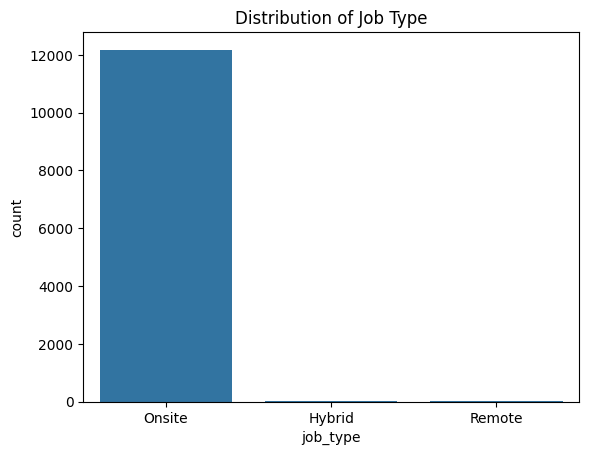

In [83]:
sns.countplot(x='job_type', data = df)
plt.title("Distribution of Job Type")
plt.show()

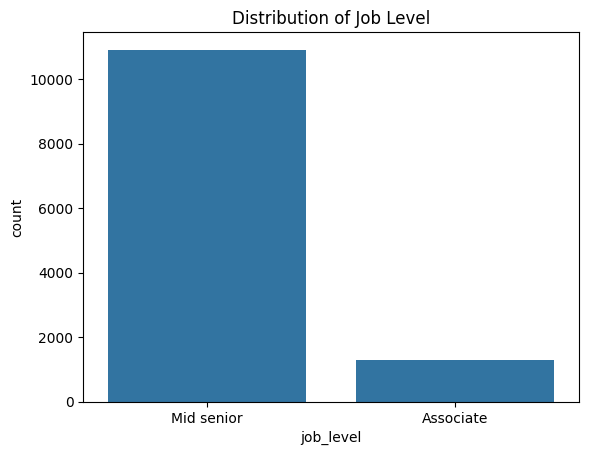

In [84]:
sns.countplot(x='job_level', data = df)
plt.title("Distribution of Job Level")
plt.show()

In [74]:
skills_list = ''
for skill in df.job_skills:
    skills_list += skill.lower()
skills_list = skills_list.split(', ')
skills_list[:10]

['machine learning',
 'programming',
 'python',
 'scala',
 'java',
 'data engineering',
 'distributed computing',
 'statistical modeling',
 'optimization',
 'data pipelines']

In [75]:
from collections import Counter
counts = Counter(skills_list)
common_skills = counts.most_common(15)
common_skills

[('python', 4399),
 ('sql', 4219),
 ('communication', 2428),
 ('data analysis', 2334),
 ('data visualization', 2259),
 ('machine learning', 2025),
 ('tableau', 1644),
 ('aws', 1615),
 ('communication skills', 1606),
 ('project management', 1572),
 ('r', 1505),
 ('data modeling', 1427),
 ('spark', 1372),
 ('problem solving', 1363),
 ('data warehousing', 1316)]

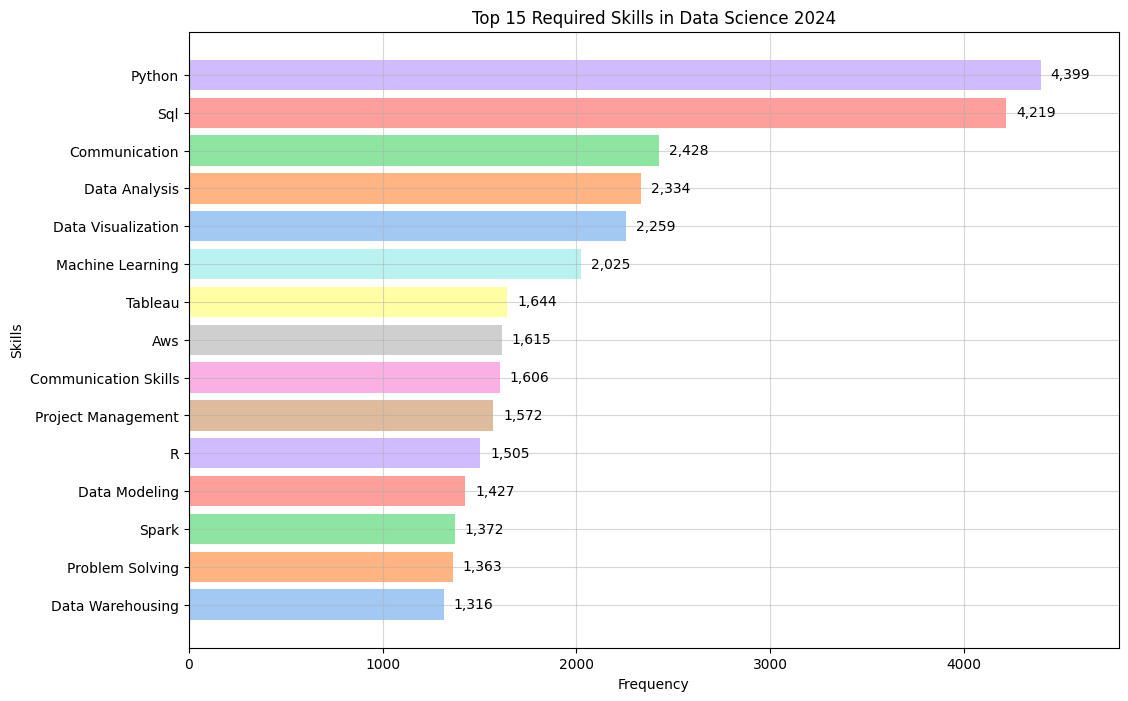

In [76]:
labels, values = zip(*common_skills)
labels = [label.title() for label in labels]
plt.figure(figsize=(12, 8))
bars = plt.barh(labels[::-1], values[::-1], color=sns.color_palette("pastel"))

for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 50
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f"{width:,.0f}", va='center', color='black')

plt.xlabel('Frequency')
plt.ylabel('Skills')
plt.title('Top 15 Required Skills in Data Science 2024', color='black')

plt.grid(axis='both', linestyle='-', alpha=0.5)

plt.xlim(0, 4800)
plt.show()

In [77]:
top2000 = counts.most_common(2000)
count2000 = Counter(dict(top2000))

In [78]:
def merge_similar_labels(count2000, similarity):
    merged_counts = {}
    merged = set()

    for label, count in count2000.items():
        if label in merged:
            continue # skip if merged

        # find similar lables with a similarity higher than given percentage%
        similar_labels = get_close_matches(label, count2000.keys(), cutoff=similarity)

        # pick the longest label as the main one
        chosen_label = min(similar_labels, key=len)

        # sum similar labels and assign to chosen label
        merged_counts[chosen_label] = sum(count2000[l] for l in similar_labels)
        if (len(list(l for l in similar_labels)) > 1):
            print(list(l for l in similar_labels), len(list(l for l in similar_labels)))

        # mark similar labels as merged
        merged.update(similar_labels)

    return merged_counts

# merge labels with similarity higher than 85%
merged_counts = merge_similar_labels(count2000, 0.85)
len(merged_counts)

['python', 'python3'] 2
['sql', 'tsql'] 2
['communication', 'communications'] 2
['data analysis', 'data analytics', 'data analyst'] 3
['data visualization', 'data visualizations', 'data visualisation'] 3
['machine learning', 'machine learning (ml)'] 2
['communication skills', 'verbal communication skills', 'strong communication skills'] 3
['project management', 'product management', 'agile project management'] 3
['data modeling', 'data modelling', 'data model'] 3
['problem solving', 'problemsolving'] 2
['data warehousing', 'data warehouse'] 2
['data management', 'metadata management', 'database management'] 3
['analytical skills', 'analytic skills'] 2
['teamwork', 'team work'] 2
['data engineering', 'data engineer', 'database engineering'] 3
['power bi', 'powerbi'] 2
['business intelligence', 'business intelligence (bi)', 'business intelligence tools'] 3
['statistics', 'biostatistics'] 2
['data integration', 'data migration', 'data interpretation'] 3
["bachelor's degree", 'bachelors de

1727

In [80]:
merged_counts = Counter(merged_counts)
merged_counts.most_common(20)

[('python', 4439),
 ('sql', 4396),
 ('data analyst', 3417),
 ('communication', 2465),
 ('data visualization', 2327),
 ('problemsolving', 2319),
 ('machine learning', 2064),
 ('project management', 1725),
 ('communication skills', 1699),
 ('tableau', 1644),
 ('aws', 1615),
 ('data management', 1526),
 ('r', 1505),
 ('spark', 1372),
 ('powerbi', 1345),
 ('teamwork', 1247),
 ('java', 1237),
 ('analytic skills', 1194),
 ('data science', 1166),
 ('data governance', 1098)]

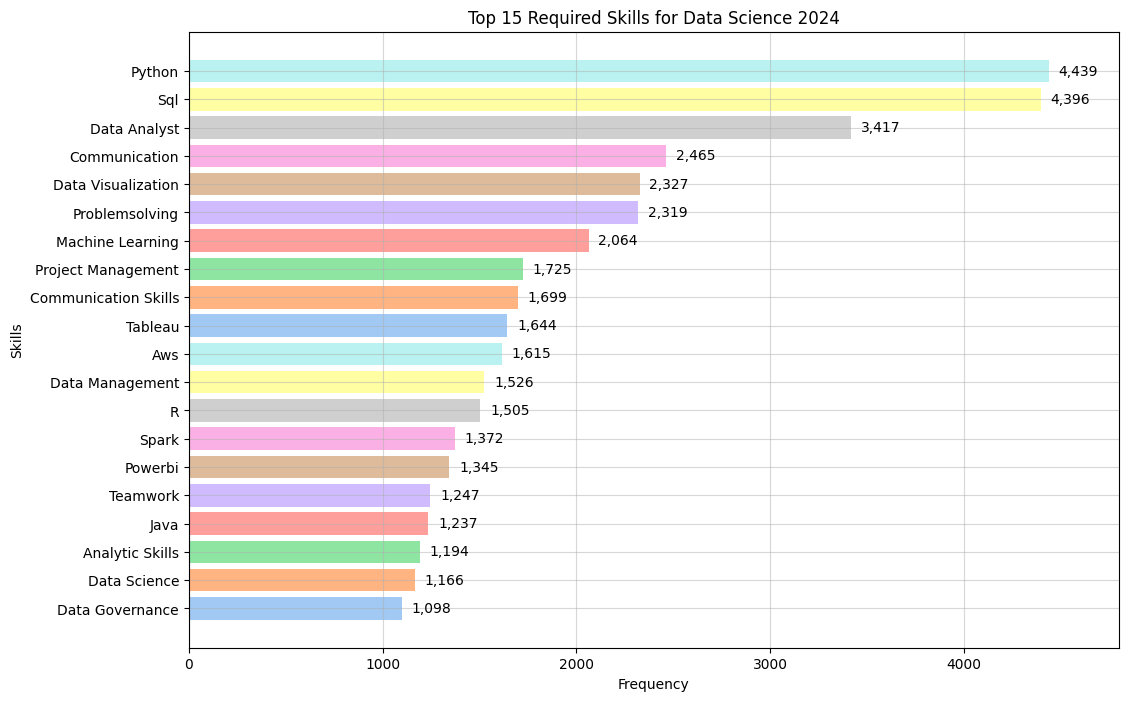

In [81]:
labels, values = zip(*merged_counts.most_common(20))
labels = [label.title() for label in labels]
plt.figure(figsize=(12, 8))
bars = plt.barh(labels[::-1], values[::-1], color=sns.color_palette("pastel"))

for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 50
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f"{width:,.0f}", va='center', color='black')

plt.xlabel('Frequency')
plt.ylabel('Skills')
plt.title('Top 15 Required Skills for Data Science 2024', color='black')

plt.grid(axis='both', linestyle='-', alpha=0.5)

plt.xlim(0, 4800)
plt.show()